In [1]:
!pip install gensim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 42.0 MB/s eta 0:00:00:00:0100:01
  Attempting uninstall: scipy
    Found existing installation: scipy 1.15.2
    Uninstalling scipy-1.15.2:
      Successfully uninstalled scipy-1.15.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tsfresh 0.21.0 requires scipy>=1.14.0; python_version >= "3.10", but you have scipy 1.13.1 which is incompatible.
nilearn 0.11.1 requires scikit-learn>=1.4.0, but you have scikit-learn 1.2.2 which is incompatible.
bigframes 1.36.0 requires rich<14,>=12.4.4, but you have rich 14.0.0 which is incompatible.
imbalanced-learn 0.13.0 requires scikit-learn<2,>=1.3.2, but you have scikit-learn 1.2.2 which is incompatible.
plotnine 0.14.5 requires matplotlib>=3.8.0, but you have matplotlib 3.7.5 which is inc

In [2]:
import gensim
from gensim.models import KeyedVectors
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [3]:
model_path = "/kaggle/input/googlenewsvectors/GoogleNews-vectors-negative300.bin"

In [6]:
model = KeyedVectors.load_word2vec_format(model_path, binary=True)

In [7]:
model['coffee'].shape

(300,)

In [8]:
model.most_similar('obama')

[('mccain', 0.731901228427887),
 ('hillary', 0.7284600138664246),
 ('obamas', 0.7229632139205933),
 ('george_bush', 0.7205674648284912),
 ('barack_obama', 0.7045838832855225),
 ('palin', 0.7043113708496094),
 ('clinton', 0.6934448480606079),
 ('clintons', 0.6816834807395935),
 ('sarah_palin', 0.6815145015716553),
 ('john_mccain', 0.6800708174705505)]

In [9]:
model.most_similar('coke')

[('heroin_ecstasy_LSD', 0.6842464804649353),
 ('coking', 0.5356490612030029),
 ('metallurgical_coke', 0.5258563160896301),
 ('cocain', 0.5173832178115845),
 ('caustic_soda', 0.510305643081665),
 ('herion', 0.5091201066970825),
 ('Refiner_Sunoco', 0.5074806809425354),
 ('cocaine', 0.49948909878730774),
 ('heroin', 0.4900570213794708),
 ('crystal_methamphetamines', 0.4898897707462311)]

In [10]:
model.most_similar('banana')

[('bananas', 0.7523775696754456),
 ('pineapple', 0.6587537527084351),
 ('mango', 0.6365211009979248),
 ('pineapples', 0.6313878297805786),
 ('papaya', 0.6063665747642517),
 ('coconut', 0.6035483479499817),
 ('potato', 0.5747568607330322),
 ('melon', 0.5625775456428528),
 ('cashew', 0.562165379524231),
 ('tomato', 0.5590206384658813)]

In [11]:
model.most_similar('language')

[('langauge', 0.747669517993927),
 ('Language', 0.6695356369018555),
 ('languages', 0.6341332197189331),
 ('English', 0.6120712757110596),
 ('CMPB_Spanish', 0.6083105206489563),
 ('nonnative_speakers', 0.6063109636306763),
 ('idiomatic_expressions', 0.5889802575111389),
 ('verb_tenses', 0.5841568112373352),
 ('Kumeyaay_Diegueno', 0.5798824429512024),
 ('dialect', 0.5724600553512573)]

In [12]:
model.most_similar("plant")

[('plants', 0.810967743396759),
 ('Plant', 0.7019316554069519),
 ('factory', 0.6708794236183167),
 ('paperboard_mill', 0.5969303250312805),
 ('containerboard_mill', 0.5863690972328186),
 ('factories', 0.57695072889328),
 ('megawatt_MW_biomass', 0.5585776567459106),
 ('refinery', 0.5582204461097717),
 ('Plants', 0.557354748249054),
 ('mill', 0.5535970330238342)]

In [13]:
model.most_similar(negative='banana')

[('NORWALK_CONN', 0.2376854419708252),
 ('JIM_HANNON_TimesDaily', 0.2376764565706253),
 ('KITCHENER_ONTARIO', 0.23705120384693146),
 ('DENVER_CO_PRWEB', 0.23474793136119843),
 ('GRANDE_BAY_MAURITIUS', 0.2316431701183319),
 ('Dr._Parviz_Azar', 0.22826240956783295),
 ('HuMax_IL8_TM', 0.22697211802005768),
 ('subsidiary_Airstar', 0.22571395337581635),
 ('AB_OMX_Stockholm', 0.22488577663898468),
 ('MotoTron_electronic_controls', 0.22116823494434357)]

In [14]:
result = model.most_similar(positive=['woman', 'king'], negative=['man'])
print("{}: {:.4f}".format(*result[0]))

queen: 0.7118


In [15]:
result = model.most_similar(positive=['italy', 'sushi'], negative=['japan'])
print("{}: {:.4f}".format(*result[0]))

gourmet_pizza: 0.5829


In [16]:
w1 = "dog"
w2 = "cat"
w3 = "fruit"
w1_w2_dist = model.distance(w1, w2)
w1_w3_dist = model.distance(w1, w3)

#dog is much closer to cat then dog to fruit
w1_w2_dist, w1_w3_dist

(0.23905432224273682, 0.8784865587949753)

In [17]:
w1 = "happy" # synonym 1
w2 = "cheerful" # synonym 2
w3 = "sad" # antonym
w1_w2_dist = model.distance(w1, w2)
w1_w3_dist = model.distance(w1, w3)

#$w_1$="happy" is closer to $w_3$="sad" than to $w_2$="cheerful"!!
#those similarlity does not handle antonym....
w1_w2_dist, w1_w3_dist

(0.6162261664867401, 0.46453857421875)

In [19]:
import pprint

In [20]:
pprint.pprint(model.most_similar(positive=['woman', 'worker'], negative=['man']))

[('workers', 0.6582455039024353),
 ('employee', 0.5805293917655945),
 ('nurse', 0.5249922275543213),
 ('receptionist', 0.5142489671707153),
 ('migrant_worker', 0.5001609921455383),
 ('Worker', 0.4979270398616791),
 ('housewife', 0.48609837889671326),
 ('registered_nurse', 0.484619140625),
 ('laborer', 0.48437267541885376),
 ('coworker', 0.48212406039237976)]


In [21]:
pprint.pprint(model.most_similar(positive=['man', 'worker'], negative=['woman']))

[('workers', 0.5590359568595886),
 ('laborer', 0.54481041431427),
 ('foreman', 0.5192232131958008),
 ('Worker', 0.5161596536636353),
 ('employee', 0.5094279646873474),
 ('electrician', 0.49481216073036194),
 ('janitor', 0.48718899488449097),
 ('bricklayer', 0.48253133893013),
 ('carpenter', 0.47499001026153564),
 ('workman', 0.46425172686576843)]


In [22]:
pprint.pprint(model.most_similar(positive=["woman", "doctor"], negative=["man"]))

[('gynecologist', 0.7093891501426697),
 ('nurse', 0.6477287411689758),
 ('doctors', 0.6471460461616516),
 ('physician', 0.6438996195793152),
 ('pediatrician', 0.6249487400054932),
 ('nurse_practitioner', 0.6218313574790955),
 ('obstetrician', 0.6072013974189758),
 ('ob_gyn', 0.5986713171005249),
 ('midwife', 0.5927063226699829),
 ('dermatologist', 0.5739566683769226)]


In [23]:
def analogy(x1, x2, y1):
    result = model.most_similar(positive=[y1, x2], negative=[x1])
    return result[0][0]

In [26]:
analogy('japan', 'sushi', 'italy')

'gourmet_pizza'

In [28]:
analogy('obama', 'clinton', 'reagan')

'kerry'

In [29]:
analogy('tall', 'tallest', 'long')

'longest'

In [30]:
analogy('good', 'fantastic', 'bad')

'horrible'

In [32]:
print(model.doesnt_match("coke pepsi sprite water".split()))

water


In [ ]:
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
words = ['coffee', 'tea', 'beer', 'wine', 'brandy', 'rum', 'champagne', 'water',
        'spaghetti', 'borscht', 'hamburger', 'pizza', 'falafel', 'sushi', 'meatballs',
        'dog', 'horse', 'cat', 'monkey', 'parrot', 'koala', 'lizard',
        'frog', 'toad', 'monkey', 'ape', 'kangaroo', 'wombat', 'wolf',
        'france', 'germany', 'hungary', 'australia', 'fiji', 'china',
        'homework', 'assignment', 'problem', 'exam', 'test', 'class',
        'school', 'college', 'university', 'institute']

In [ ]:
word_vectors = np.array([model[w] for w in words])
twodim = PCA().fit_transform(word_vectors)[:,:2]

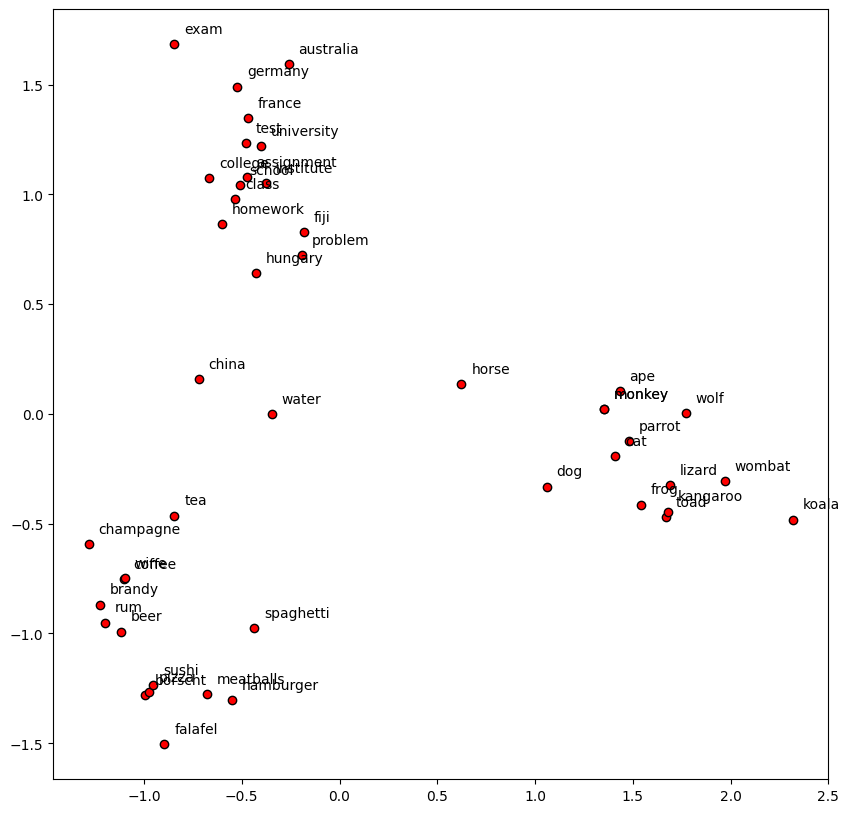

In [34]:
plt.figure(figsize=(10,10))
plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
for word, (x,y) in zip(words, twodim):
    plt.text(x+0.05, y+0.05, word)
plt.show()

In [ ]:
# Now using some other model 

In [42]:
model_path = "/kaggle/input/glove300d-word2vec-bin/glove.840B.300d_word2vec.bin"

In [44]:
model = KeyedVectors.load_word2vec_format(model_path, binary=True)

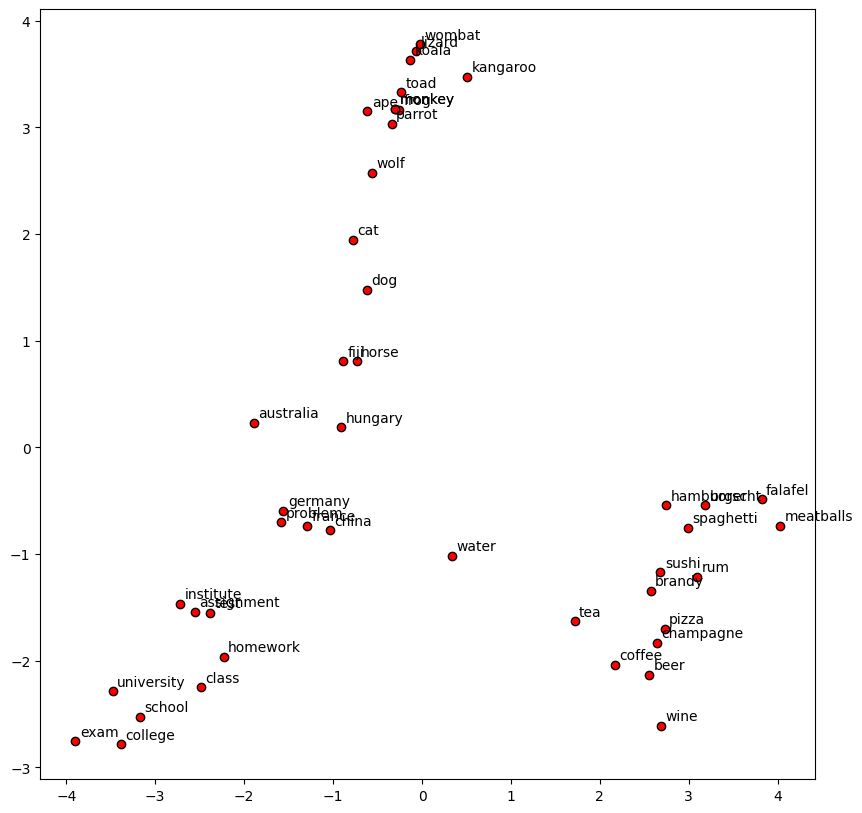

In [45]:
word_vectors = np.array([model[w] for w in words])

twodim = PCA().fit_transform(word_vectors)[:,:2]  #transform 100 to 2 dimensions

plt.figure(figsize=(10,10))
plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
for word, (x,y) in zip(words, twodim):
    plt.text(x+0.05, y+0.05, word)
plt.show()